========== 1. ИМПОРТ БИБЛИОТЕК ==========

In [1]:
# Библиотеки для работы с данными
import pandas as pd
import numpy as np

# Библиотеки для визуализации (рисования графиков)
import matplotlib.pyplot as plt
import seaborn as sns


========== 2. ЗАГРУЗКА ДАННЫХ ==========

In [2]:
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)
#print(df.head())
#print("\n\nИнформация о данных:")
#print(df.info())

print(f"Загружено строк: {len(df)}")
print(f"Количество столбцов: {len(df.columns)}")
print("\nПервые 5 строк:")
display(df.head())

print("\nИнформация о данных:")
df.info()




Saving new_final.csv to new_final (2).csv
Загружено строк: 1270
Количество столбцов: 10

Первые 5 строк:


,name,type,category,abv,ibu,srm,og,fg,rs,master_type
0,Brazillionaire Semi-Sweet Mead,Standard Mead,Mead,8.9,NaN,NaN,1.078,1.014,0.064,Traditional Mead
1,Frankenbutter! Specialty Mead,Experimental Mead,Mead,12.5,NaN,38.0,1.158,1.084,0.074,Experimental Mead
2,Challenge Accepted American Amber Ale,American Amber Ale,Beer,5.7,33.0,15.0,1.056,1.014,0.042,Ale
3,Horizon Pale Ale,American Pale Ale,Beer,6.5,57.0,7.0,1.057,1.009,0.048,Ale
4,One Way or Another Guava Blonde Ale,Fruit Beer,Beer,3.4,18.0,4.0,1.032,1.006,0.026,Ale



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1270 entries, 0 to 1269
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         1270 non-null   object 
 1   type         1270 non-null   object 
 2   category     1270 non-null   object 
 3   abv          1176 non-null   float64
 4   ibu          850 non-null    float64
 5   srm          818 non-null    float64
 6   og           1249 non-null   float64
 7   fg           1165 non-null   float64
 8   rs           1124 non-null   float64
 9   master_type  1270 non-null   object 
dtypes: float64(6), object(4)
memory usage: 99.3+ KB


 0 **name**     -   Название напитка

 1 **type**     -  Тип напитка

 2 **category** - Категория напитка  

 3 **abv**      -   Alcohol By Volume - объемная доля алкоголя (в процентах)

 4 **ibu**      -     International Bitterness Units - международные единицы горечи (чем выше значение, тем более горькое пиво)

 5 **srm**      -     Standard Reference Method - цвет пива (чем выше число, тем темнее пиво)

 6 **og**       -      Original Gravity - начальная плотность сусла до брожения. Измеряет количество сахара в растворе (чем выше OG, тем больше потенциального алкоголя)

 7 **fg**       -       Final Gravity - конечная плотность после брожения. Показывает, сколько сахара осталось (разница OG - FG определяет количество алкоголя)

 8 **rs**       -      Residual Sugar - остаточный сахар (в процентах). Показывает, сколько сахара осталось в напитке после брожения

 9 **master_type** - Разновидность напитка

========== 3. ПОДГОТОВКА ДАННЫХ ==========

========== 3.1 Заполнение пропусков

In [3]:
# Считаем пропуски в каждом столбце
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Столбцы с пропусками:")
print(missing)
print(f"\nВсего строк в данных: {len(df)}")


Столбцы с пропусками:
srm    452
ibu    420
rs     146
fg     105
abv     94
og      21
dtype: int64

Всего строк в данных: 1270


========== 3.2 Удаление строк

In [4]:
df_clean = df.dropna(subset=['abv']).copy()

removed = len(df) - len(df_clean)
print(f"Удалено строк: {removed}")


# Запоминаем, какие столбцы будем заполнять
cols_to_fill = ['ibu', 'srm', 'og', 'fg', 'rs']

# Для каждого столбца считаем медиану и заполняем
# Медиана лучше среднего, потому что она не реагирует на выбросы
for col in cols_to_fill:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"{col}: заполнено медианой = {median_val:.3f}")

print(f"Осталось строк: {len(df_clean)}")


Удалено строк: 94
ibu: заполнено медианой = 30.000
srm: заполнено медианой = 9.845
og: заполнено медианой = 1.059
fg: заполнено медианой = 1.013
rs: заполнено медианой = 0.047
Осталось строк: 1176


========== 3.3 Создание нового признака

In [5]:
# ============================================
# СОЗДАЕМ НОВЫЙ ПРИЗНАК ATTENUATION
# ============================================

print("\nСОЗДАНИЕ НОВОГО ПРИЗНАКА\n")

# Attenuation показывает, сколько сахара сбродило в алкоголь
# Формула: (OG - FG) / OG * 100
# Чем выше число, тем больше сахара превратилось в алкоголь

df_clean['attenuation'] = ((df_clean['og'] - df_clean['fg']) / df_clean['og']) * 100

# Округляем до 3 знаков для чистоты данных
df_clean['attenuation'] = df_clean['attenuation'].round(3)

print("Создан новый признак: 'attenuation'")

print(df_clean[['og', 'fg', 'attenuation']].head())



СОЗДАНИЕ НОВОГО ПРИЗНАКА

Создан новый признак: 'attenuation'
      og     fg  attenuation
0  1.078  1.014        5.937
1  1.158  1.084        6.390
2  1.056  1.014        3.977
3  1.057  1.009        4.541
4  1.032  1.006        2.519


In [6]:
# ============================================
# ПРОВЕРЯЕМ РЕЗУЛЬТАТ
# ============================================

print("\nПРОВЕРКА ОЧИСТКИ\n")

# Проверяем пропуски
print("Пропусков в данных:", df_clean.isnull().sum().sum())

# Выводим информацию о данных
print("\nИНФОРМАЦИЯ О ДАННЫХ:")
df_clean.info()
df_clean.head()



ПРОВЕРКА ОЧИСТКИ

Пропусков в данных: 0

ИНФОРМАЦИЯ О ДАННЫХ:
<class 'pandas.core.frame.DataFrame'>
Index: 1176 entries, 0 to 1269
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         1176 non-null   object 
 1   type         1176 non-null   object 
 2   category     1176 non-null   object 
 3   abv          1176 non-null   float64
 4   ibu          1176 non-null   float64
 5   srm          1176 non-null   float64
 6   og           1176 non-null   float64
 7   fg           1176 non-null   float64
 8   rs           1176 non-null   float64
 9   master_type  1176 non-null   object 
 10  attenuation  1176 non-null   float64
dtypes: float64(7), object(4)
memory usage: 110.2+ KB


,name,type,category,abv,ibu,srm,og,fg,rs,master_type,attenuation
0,Brazillionaire Semi-Sweet Mead,Standard Mead,Mead,8.9,30.0,9.845,1.078,1.014,0.064,Traditional Mead,5.937
1,Frankenbutter! Specialty Mead,Experimental Mead,Mead,12.5,30.0,38.000,1.158,1.084,0.074,Experimental Mead,6.390
2,Challenge Accepted American Amber Ale,American Amber Ale,Beer,5.7,33.0,15.000,1.056,1.014,0.042,Ale,3.977
3,Horizon Pale Ale,American Pale Ale,Beer,6.5,57.0,7.000,1.057,1.009,0.048,Ale,4.541
4,One Way or Another Guava Blonde Ale,Fruit Beer,Beer,3.4,18.0,4.000,1.032,1.006,0.026,Ale,2.519


========== 4. Кодирование категориальных признаков ==========

In [7]:

from sklearn.preprocessing import LabelEncoder

categorical_cols = ['type', 'category', 'master_type']

# Удаляем столбец 'name' — он не пригодится для анализа модели
df_clean = df_clean.drop('name', axis=1, errors='ignore')

# ---------- One-Hot Encoding ----------
# Для линейных моделей (Linear Regression, Ridge), KNN и Dummy
df_onehot = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)


# ---------- Label Encoding ----------
# Для деревьев (Random Forest, Extra Trees, Decision Tree)
# Для бустингов (Gradient Boosting, XGBoost) (кроме CatBoost)
df_label = df_clean.copy()
for col in categorical_cols:
    le = LabelEncoder()
    df_label[col] = le.fit_transform(df_label[col].astype(str))


# ---------- CatBoost (без кодирования) ----------
# Для CatBoost текстовые столбцы type, category, master_type остаются текстовыми

df_catboost = df_clean.copy()

print("Данные закодированы:")
print(f"df_onehot:    {df_onehot.shape}  (Linear, Ridge, KNN, Dummy)")
print(f"df_label:     {df_label.shape}   (Decision Tree, Random Forest, Extra Trees, Gradient Boosting, XGBoost)")
print(f"df_catboost:  {df_catboost.shape} (CatBoost - с текстовыми категориями)")


Данные закодированы:
df_onehot:    (1176, 130)  (Linear, Ridge, KNN, Dummy)
df_label:     (1176, 10)   (Decision Tree, Random Forest, Extra Trees, Gradient Boosting, XGBoost)
df_catboost:  (1176, 10) (CatBoost - с текстовыми категориями)


========== 5. РАЗДЕЛЕНИЕ НА ПРИЗНАКИ (X) И ЦЕЛЬ (y) ==========

In [8]:
# Словарь с признаками для каждой версии
X_data = {
    'onehot': df_onehot.drop('abv', axis=1),
    'label': df_label.drop('abv', axis=1),
    'catboost': df_catboost.drop(['abv', 'name'], axis=1, errors='ignore')
}

for name, X in X_data.items():
    print(f"  X_{name}: {X.shape} (признаки)")

# Целевая переменная (общая для всех)
y = df_onehot['abv']
print(f"\nЦелевая переменная y: {y.shape}")


  X_onehot: (1176, 129) (признаки)
  X_label: (1176, 9) (признаки)
  X_catboost: (1176, 9) (признаки)

Целевая переменная y: (1176,)


========== 6. РАЗДЕЛЕНИЕ НА TRAIN/TEST ==========

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Разделяем все версии
train_test_sets = {}
for name, X in X_data.items():
    X_train, X_test, _, _ = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    train_test_sets[f'X_train_{name}'] = X_train
    train_test_sets[f'X_test_{name}'] = X_test

# Сохраняем y_train, y_test (нужны для всех моделей)
_, _, y_train, y_test = train_test_split(
    X_data['onehot'], y, test_size=0.2, random_state=42
)

# Извлекаем для сокращения имен переменных
X_train_onehot = train_test_sets['X_train_onehot']
X_test_onehot = train_test_sets['X_test_onehot']
X_train_label = train_test_sets['X_train_label']
X_test_label = train_test_sets['X_test_label']
X_train_catboost = train_test_sets['X_train_catboost']
X_test_catboost = train_test_sets['X_test_catboost']


print("Данные разделены:")
for name in ['onehot', 'label', 'catboost']:
    X_train = train_test_sets[f'X_train_{name}']
    X_test = train_test_sets[f'X_test_{name}']
    print(f"  {name}: train {X_train.shape}, test {X_test.shape}")

# ---------- Масштабирование ----------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_onehot)
X_test_scaled = scaler.transform(X_test_onehot)

print(f"\nМасштабирование выполнено для линейных моделей (Linear Regression, Ridge) и KNN:")
print(f"  X_train_scaled: {X_train_scaled.shape}")
print(f"  X_test_scaled:  {X_test_scaled.shape}")

# ---------- ПРОВЕРКА ----------
print("\n" + "-"*30)
print("ПРОВЕРКА РАЗМЕРОВ")
print("-"*30)

for name in ['onehot', 'label', 'catboost']:
    X_train = train_test_sets[f'X_train_{name}']
    print(f"{name}: {X_train.shape[0]} == {y_train.shape[0]} -> {X_train.shape[0] == y_train.shape[0]}")

print("\nПроверка: сумма train + test = исходный размер")
for name, X in X_data.items():
    X_train = train_test_sets[f'X_train_{name}']
    X_test = train_test_sets[f'X_test_{name}']
    correct = X_train.shape[0] + X_test.shape[0] == X.shape[0]
    print(f"  {name}: {X_train.shape[0]} + {X_test.shape[0]} = {X.shape[0]} -> {correct}")

print("\nПроверка пропусков:")
for name in ['onehot', 'label', 'catboost']:
    X_train = train_test_sets[f'X_train_{name}']
    print(f"  X_train_{name}: {X_train.isnull().sum().sum()} пропусков")


Данные разделены:
  onehot: train (940, 129), test (236, 129)
  label: train (940, 9), test (236, 9)
  catboost: train (940, 9), test (236, 9)

Масштабирование выполнено для линейных моделей (Linear Regression, Ridge) и KNN:
  X_train_scaled: (940, 129)
  X_test_scaled:  (236, 129)

------------------------------
ПРОВЕРКА РАЗМЕРОВ
------------------------------
onehot: 940 == 940 -> True
label: 940 == 940 -> True
catboost: 940 == 940 -> True

Проверка: сумма train + test = исходный размер
  onehot: 940 + 236 = 1176 -> True
  label: 940 + 236 = 1176 -> True
  catboost: 940 + 236 = 1176 -> True

Проверка пропусков:
  X_train_onehot: 0 пропусков
  X_train_label: 0 пропусков
  X_train_catboost: 0 пропусков


========== 7. ПОДГОТОВКА К ОБУЧЕНИЮ ==========

In [10]:
!pip install xgboost catboost -q

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# В НАЧАЛЕ: создаем словарь для хранения предсказаний
predictions = {}  # ← ВСТАВИТЬ ЭТУ СТРОКУ

# Создаем списки для результатов
model_names = []
mae_scores = []
r2_scores = []



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.7 MB/s eta 0:00:00


============= 7.1 Обучение Dummy Regressor

In [11]:
# ----- Dummy -----
print("\n1. Dummy...")
model = DummyRegressor(strategy='mean')
model.fit(X_train_label, y_train)
y_pred = model.predict(X_test_label)

predictions['Dummy'] = y_pred

model_names.append('Dummy')
mae_scores.append(mean_absolute_error(y_test, y_pred))
r2_scores.append(r2_score(y_test, y_pred))
print(f"   MAE: {mae_scores[-1]:.4f}, R2: {r2_scores[-1]:.4f}")



1. Dummy...
   MAE: 2.0192, R2: -0.0110


=========== 7.2 Обучение линейных моделей

In [12]:
# ============================================
# ЛИНЕЙНЫЕ МОДЕЛИ
# ============================================

# ----- Linear Regression -----
print("\n2. Linear Regression...")
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

predictions['Linear Regression'] = y_pred

model_names.append('Linear Regression')
mae_scores.append(mean_absolute_error(y_test, y_pred))
r2_scores.append(r2_score(y_test, y_pred))
print(f"   MAE: {mae_scores[-1]:.4f}, R2: {r2_scores[-1]:.4f}")



# ----- Ridge -----
print("\n3. Ridge...")
model = Ridge(alpha=1.0)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

predictions['Ridge'] = y_pred

model_names.append('Ridge')
mae_scores.append(mean_absolute_error(y_test, y_pred))
r2_scores.append(r2_score(y_test, y_pred))
print(f"   MAE: {mae_scores[-1]:.4f}, R2: {r2_scores[-1]:.4f}")



2. Linear Regression...
   MAE: 0.4330, R2: 0.7882

3. Ridge...
   MAE: 0.4306, R2: 0.7918


========== 7.3 Обучение К ближайших соседей

In [13]:
# ----- KNN -----
print("\n4. KNN...")
model = KNeighborsRegressor(n_neighbors=5)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

predictions['KNN'] = y_pred

model_names.append('KNN')
mae_scores.append(mean_absolute_error(y_test, y_pred))
r2_scores.append(r2_score(y_test, y_pred))
print(f"   MAE: {mae_scores[-1]:.4f}, R2: {r2_scores[-1]:.4f}")



4. KNN...
   MAE: 0.8301, R2: 0.4044


========== 7.4 Обучение Decision Tree

In [14]:
# ----- Decision Tree -----
print("\n5. Decision Tree...")
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train_label, y_train)
y_pred = model.predict(X_test_label)

predictions['Decision Tree'] = y_pred

model_names.append('Decision Tree')
mae_scores.append(mean_absolute_error(y_test, y_pred))
r2_scores.append(r2_score(y_test, y_pred))
print(f"   MAE: {mae_scores[-1]:.4f}, R2: {r2_scores[-1]:.4f}")



5. Decision Tree...
   MAE: 0.5958, R2: -3.0142


========== 7.5 Обучение ансамблей (БЭГГИНГ)



In [15]:
# ----- Random Forest -----
print("\n6. Random Forest...")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_label, y_train)
y_pred = model.predict(X_test_label)

predictions['Random Forest'] = y_pred

model_names.append('Random Forest')
mae_scores.append(mean_absolute_error(y_test, y_pred))
r2_scores.append(r2_score(y_test, y_pred))
print(f"   MAE: {mae_scores[-1]:.4f}, R2: {r2_scores[-1]:.4f}")

# ----- Extra Trees -----
print("\n7. Extra Trees...")
model = ExtraTreesRegressor(n_estimators=100, random_state=42)
model.fit(X_train_label, y_train)
y_pred = model.predict(X_test_label)

predictions['Extra Trees'] = y_pred

model_names.append('Extra Trees')
mae_scores.append(mean_absolute_error(y_test, y_pred))
r2_scores.append(r2_score(y_test, y_pred))
print(f"   MAE: {mae_scores[-1]:.4f}, R2: {r2_scores[-1]:.4f}")




6. Random Forest...
   MAE: 0.4024, R2: 0.5680

7. Extra Trees...
   MAE: 0.3268, R2: 0.8718


========== 7.6 Обучение ансамблей (БУСТИНГ)

In [16]:
# ----- Gradient Boosting -----
print("\n8. Gradient Boosting...")
model = GradientBoostingRegressor(n_estimators=100, random_state=42)
model.fit(X_train_label, y_train)
y_pred = model.predict(X_test_label)

predictions['Gradient Boosting'] = y_pred

model_names.append('Gradient Boosting')
mae_scores.append(mean_absolute_error(y_test, y_pred))
r2_scores.append(r2_score(y_test, y_pred))
print(f"   MAE: {mae_scores[-1]:.4f}, R2: {r2_scores[-1]:.4f}")


# ----- XGBoost -----
print("\n9. XGBoost...")
model = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
model.fit(X_train_label, y_train)
y_pred = model.predict(X_test_label)

predictions['XGBoost'] = y_pred

model_names.append('XGBoost')
mae_scores.append(mean_absolute_error(y_test, y_pred))
r2_scores.append(r2_score(y_test, y_pred))
print(f"   MAE: {mae_scores[-1]:.4f}, R2: {r2_scores[-1]:.4f}")


# ----- CatBoost -----
print("\n10. CatBoost...")
model = CatBoostRegressor(
    n_estimators=100,
    random_state=42,
    verbose=False,
    cat_features=[0, 1, 7]  # type, category, master_type
)
model.fit(X_train_catboost, y_train)
y_pred = model.predict(X_test_catboost)

predictions['CatBoost'] = y_pred

model_names.append('CatBoost')
mae_scores.append(mean_absolute_error(y_test, y_pred))
r2_scores.append(r2_score(y_test, y_pred))
print(f"   MAE: {mae_scores[-1]:.4f}, R2: {r2_scores[-1]:.4f}")



8. Gradient Boosting...
   MAE: 0.2744, R2: 0.9528

9. XGBoost...
   MAE: 0.3654, R2: 0.6374

10. CatBoost...
   MAE: 0.4614, R2: 0.1724


========== 8. АНАЛИЗ МЕТРИК ==========


АНАЛИЗ МЕТРИК КАЧЕСТВА МОДЕЛЕЙ


,Модель,MAE,R2
7,Gradient Boosting,0.274410,0.952807
6,Extra Trees,0.326802,0.871844
8,XGBoost,0.365400,0.637426
5,Random Forest,0.402433,0.567986
2,Ridge,0.430583,0.791835
1,Linear Regression,0.433039,0.788161
9,CatBoost,0.461387,0.172388
4,Decision Tree,0.595768,-3.014224
3,KNN,0.830089,0.404362
0,Dummy,2.019155,-0.011012


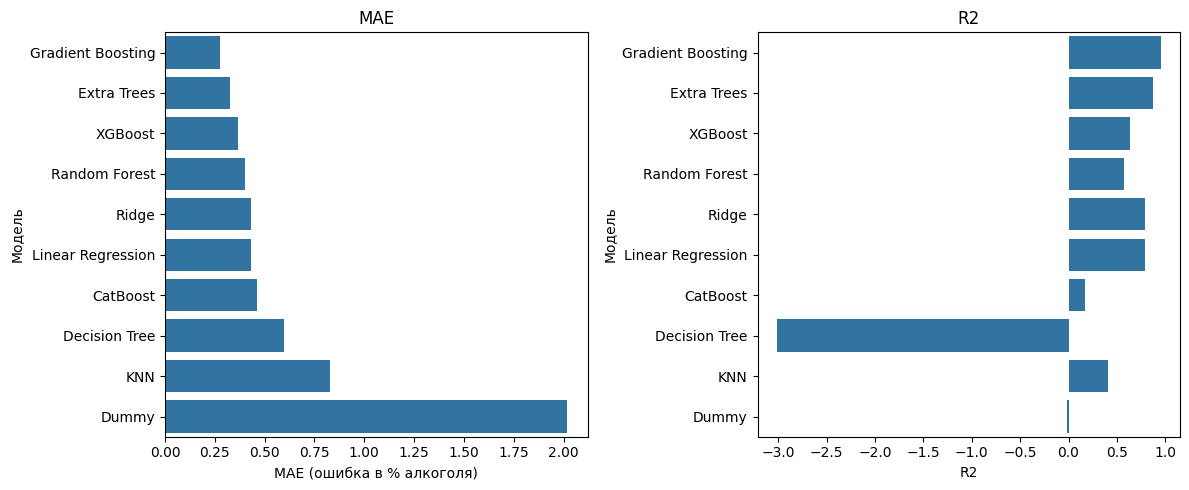

In [17]:

# import matplotlib.pyplot as plt
# import seaborn as sns

print("\n" + "="*60)
print("АНАЛИЗ МЕТРИК КАЧЕСТВА МОДЕЛЕЙ")
print("="*60)

# Создаем DataFrame с результатами
results_df = pd.DataFrame({
    'Модель': model_names,
    'MAE': mae_scores,
    'R2': r2_scores
})


# Сортируем по MAE (от лучшей к худшей)
results_df = results_df.sort_values('MAE')

# Выводим таблицу по метрикам
display(results_df)



# ---------- ВИЗУАЛИЗАЦИЯ ----------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# График 1: MAE (меньше = лучше)
sns.barplot(data=results_df, x='MAE', y='Модель', ax=axes[0])
axes[0].set_title('MAE', fontsize=12)
axes[0].set_xlabel('MAE (ошибка в % алкоголя)')

# График 2: R2 (больше = лучше)
sns.barplot(data=results_df, x='R2', y='Модель', ax=axes[1])
axes[1].set_title('R2', fontsize=12)
axes[1].set_xlabel('R2')

plt.tight_layout()
plt.show()

========== 9. АНАЛИЗ ПРЕДСКАЗАНИЙ ==========

=========== 9.1 Сводная таблица

In [18]:
# ============================================
# ТАБЛИЦА С ПРЕДСКАЗАНИЯМИ ВСЕХ МОДЕЛЕЙ
# ============================================

# 1. Создаем DataFrame с фактическими значениями
predictions_df = pd.DataFrame({
    'Фактическое ABV': y_test.values
})

# 2. Добавляем предсказания всех моделей из словаря predictions
for model_name in predictions.keys():
    predictions_df[model_name] = predictions[model_name]

# 3. Вывод информации
print("="*60)
print("ТАБЛИЦА С ПРЕДСКАЗАНИЯМИ ВСЕХ МОДЕЛЕЙ")
print("="*60)
print(f"Строк: {len(predictions_df)}")
print(f"Моделей: {len(predictions.keys())}")
print(f"Всего столбцов: {len(predictions_df.columns)}")

# 4. Показываем первые строки
display(predictions_df.head())


ТАБЛИЦА С ПРЕДСКАЗАНИЯМИ ВСЕХ МОДЕЛЕЙ
Строк: 236
Моделей: 10
Всего столбцов: 11


,Фактическое ABV,Dummy,Linear Regression,Ridge,KNN,Decision Tree,Random Forest,Extra Trees,Gradient Boosting,XGBoost,CatBoost
0,6.1,6.966593,6.190429,6.164616,6.640,6.00,5.927912,5.931912,5.704635,5.987147,5.803074
1,5.0,6.966593,4.919580,4.963111,5.270,5.10,5.011900,5.000275,4.904949,4.971030,5.215801
2,17.3,6.966593,14.112961,14.534303,11.442,14.25,14.169800,14.285400,14.297685,15.147187,14.482915
3,5.5,6.966593,5.681625,5.730714,6.740,5.60,5.591700,5.570000,5.625068,5.652862,5.423711
4,4.5,6.966593,6.481400,6.371123,4.948,4.45,5.304100,5.861200,5.469181,6.135487,5.894406


=========== 9.2 Визуализация предсказаний

ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ

ФАКТИЧЕСКИЕ vs ПРЕДСКАЗАННЫЕ ЗНАЧЕНИЯ



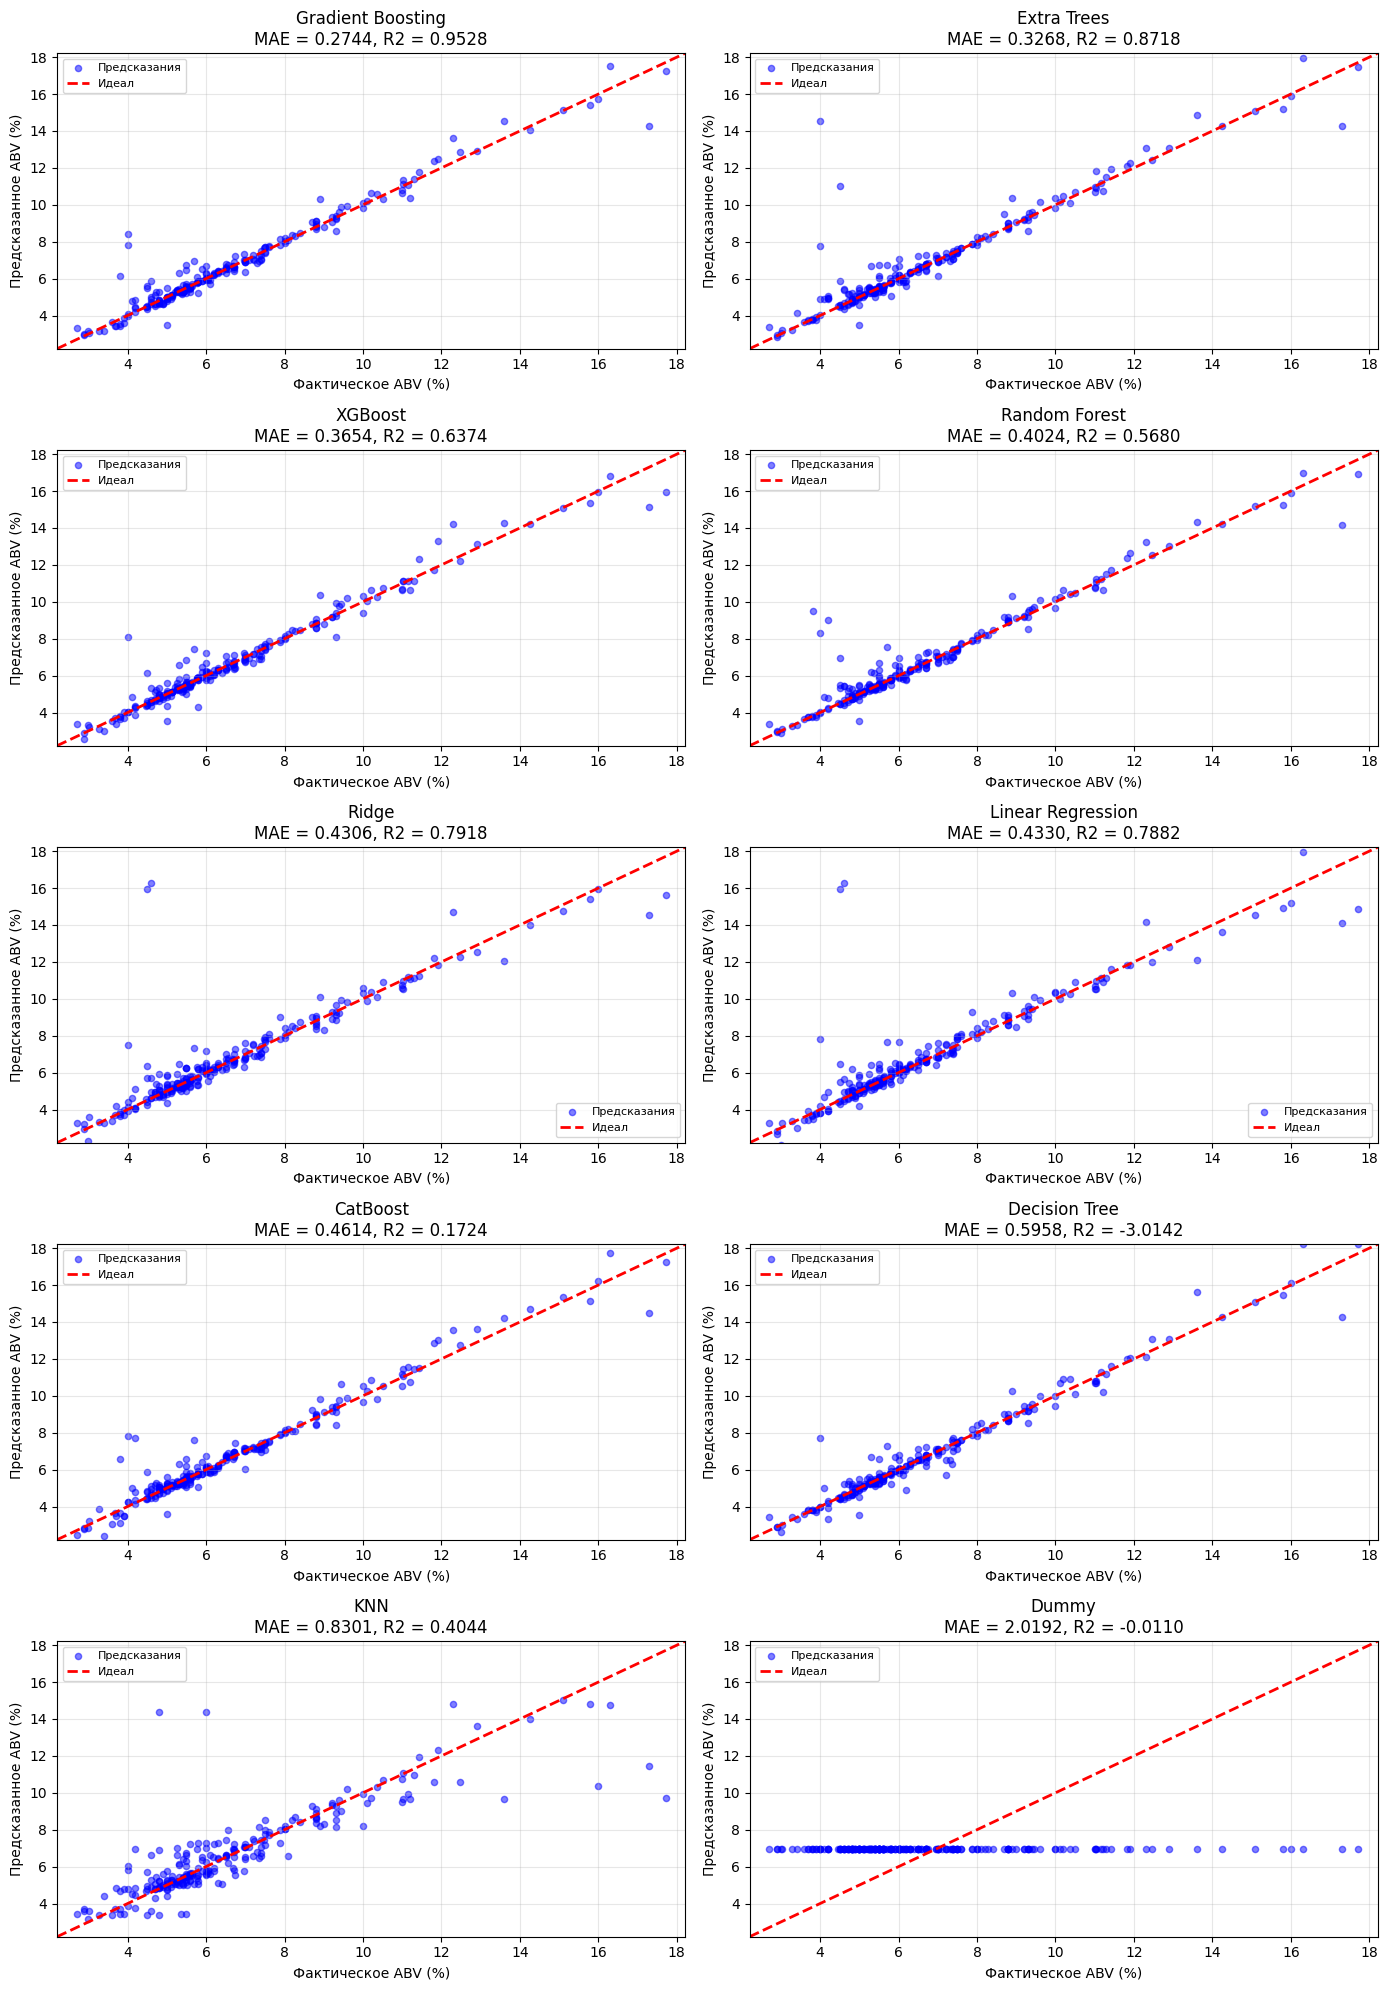

In [19]:
print("="*60)
print("ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ")
print("="*60)

# ============================================
# ТОЧЕЧНЫЙ ГРАФИК
# ============================================

print("\nФАКТИЧЕСКИЕ vs ПРЕДСКАЗАННЫЕ ЗНАЧЕНИЯ\n")

model_order = results_df['Модель'].tolist()
n_models = len(model_order)
n_rows = (n_models + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))
axes = axes.flatten()

# Общий диапазон для всех графиков (чтобы было честное сравнение)
x_min = y_test.min() - 0.5
x_max = y_test.max() + 0.5

for idx, model_name in enumerate(model_order):
    ax = axes[idx]
    y_pred = predictions[model_name]

    # Точки (предсказанные vs фактические)
    ax.scatter(y_test, y_pred, alpha=0.5, s=20, color='blue', label='Предсказания')

    # Диагональ (идеальное предсказание)
    ax.plot([x_min, x_max], [x_min, x_max], 'r--', lw=2, label='Идеал')

    # Метрики
    mae = results_df[results_df['Модель'] == model_name]['MAE'].values[0]
    r2 = results_df[results_df['Модель'] == model_name]['R2'].values[0]

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(x_min, x_max)
    ax.set_xlabel('Фактическое ABV (%)')
    ax.set_ylabel('Предсказанное ABV (%)')
    ax.set_title(f'{model_name}\nMAE = {mae:.4f}, R2 = {r2:.4f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

if n_models % 2 != 0:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()


========== 9.3 Визуализация ошибок моделей

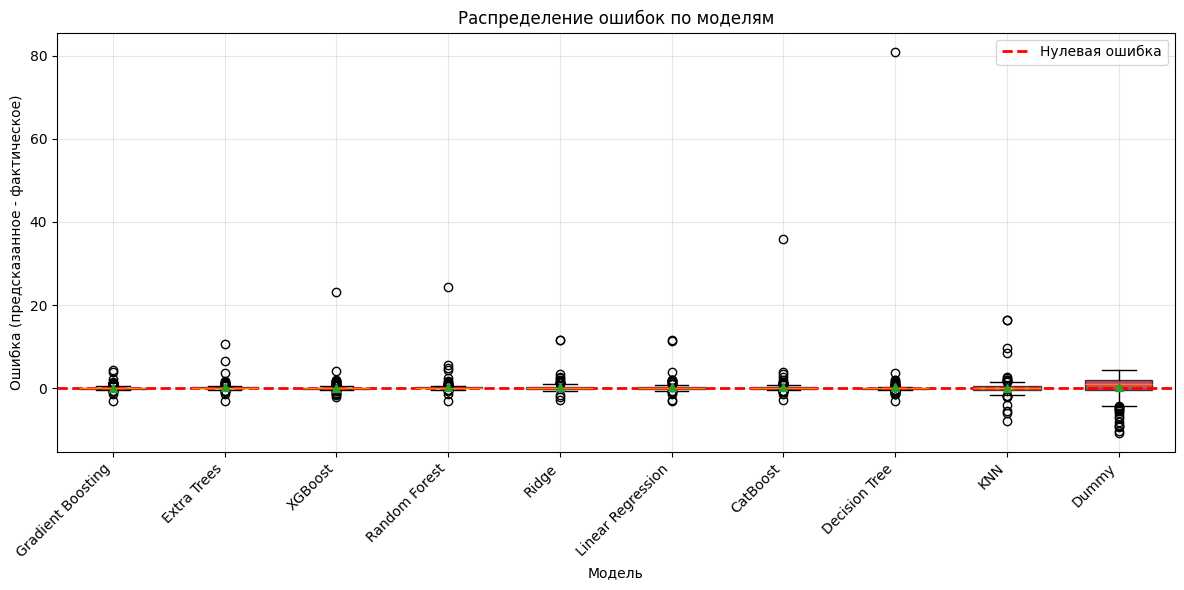

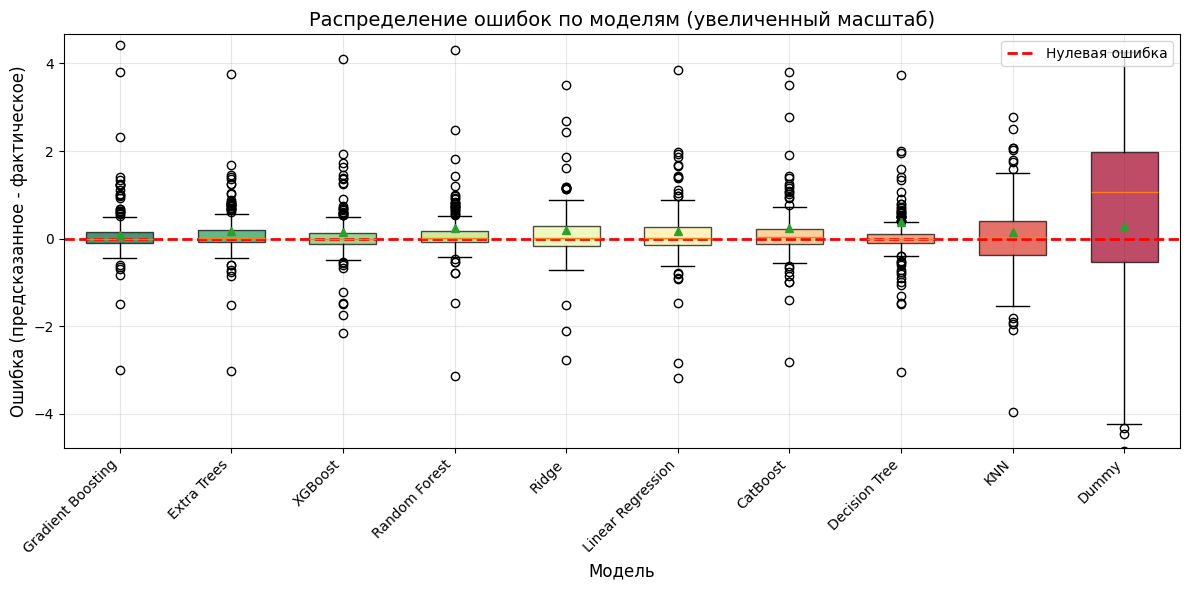


Масштаб boxplot:
  Нижняя граница: -4.7788 (-3.9913 = 1-й процентиль)
  Верхняя граница: 4.6714 (3.8839 = 99-й процентиль)


In [20]:
# ============================================
# BOXPLOT: РАСПРЕДЕЛЕНИЕ ОШИБОК ДЛЯ ВСЕХ МОДЕЛЕЙ
# ============================================

# Собираем ошибки всех моделей (отсортированные по MAE)
model_order = results_df['Модель'].tolist()
errors_df = pd.DataFrame({name: predictions[name] - y_test for name in model_order})

# Строим boxplot (используем matplotlib, а не pandas)
fig, ax = plt.subplots(figsize=(12, 6))

# Подготовка данных для boxplot
data_to_plot = [errors_df[col].dropna().values for col in errors_df.columns]

# Рисуем boxplot через matplotlib
bp = ax.boxplot(data_to_plot,
                patch_artist=True,
                showmeans=True,
                meanline=False,
                widths=0.6,
                tick_labels=model_order)   # ← ИСПРАВЛЕНО: labels → tick_labels

# Цвета по MAE (зелёный → лучший, красный → худший)
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(model_order)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Нулевая ошибка')
ax.set_xlabel('Модель')
ax.set_ylabel('Ошибка (предсказанное - фактическое)')
ax.set_title('Распределение ошибок по моделям')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Поворачиваем подписи, чтобы не накладывались
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()



# ============================================
# УВЕЛИЧЕННЫЙ BOXPLOT: РАСПРЕДЕЛЕНИЕ ОШИБОК ДЛЯ ВСЕХ МОДЕЛЕЙ
# ============================================

# Собираем ошибки всех моделей
model_order = results_df['Модель'].tolist()
errors_df = pd.DataFrame({name: predictions[name] - y_test for name in model_order})

# Находим общий диапазон ошибок (без учёта выбросов)
all_errors = np.concatenate([errors_df[col].dropna().values for col in errors_df.columns])
lower_bound = np.percentile(all_errors, 1)
upper_bound = np.percentile(all_errors, 99)
margin = (upper_bound - lower_bound) * 0.1
ylim_min = lower_bound - margin
ylim_max = upper_bound + margin

# Строим увеличенный boxplot
fig, ax = plt.subplots(figsize=(12, 6))

data_to_plot = [errors_df[col].dropna().values for col in errors_df.columns]

bp = ax.boxplot(data_to_plot,
                patch_artist=True,
                showmeans=True,
                meanline=False,
                widths=0.6,
                tick_labels=model_order,      # ← ИСПРАВЛЕНО: labels → tick_labels
                whis=1.5)

# Цвета по MAE
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(model_order)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Увеличенный масштаб
ax.set_ylim(ylim_min, ylim_max)

# Красная линия на 0
ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Нулевая ошибка')

# Подписи
ax.set_xlabel('Модель', fontsize=12)
ax.set_ylabel('Ошибка (предсказанное - фактическое)', fontsize=12)
ax.set_title('Распределение ошибок по моделям (увеличенный масштаб)', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# ---- ИНФОРМАЦИЯ О МАСШТАБЕ ----
print(f"\nМасштаб boxplot:")
print(f"  Нижняя граница: {ylim_min:.4f} ({lower_bound:.4f} = 1-й процентиль)")
print(f"  Верхняя граница: {ylim_max:.4f} ({upper_bound:.4f} = 99-й процентиль)")

========== 9.4 Статистика ошибок

In [21]:
# Статистика ошибок
print("="*60)
print("СТАТИСТИКА ОШИБОК ПО МОДЕЛЯМ")
print("="*60)
display(errors_df.describe().T.round(4))

СТАТИСТИКА ОШИБОК ПО МОДЕЛЯМ


,count,mean,std,min,25%,50%,75%,max
Gradient Boosting,236.0,0.0876,0.5689,-3.0023,-0.1071,0.0015,0.1439,4.4154
Extra Trees,236.0,0.1675,0.9336,-3.0146,-0.0752,0.0193,0.1918,10.5320
XGBoost,236.0,0.1498,1.5884,-2.1528,-0.1137,-0.0006,0.1361,23.1408
Random Forest,236.0,0.2381,1.7251,-3.1302,-0.0772,0.0181,0.1632,24.3669
Ridge,236.0,0.1858,1.1945,-2.7657,-0.1770,0.0190,0.2824,11.6732
Linear Regression,236.0,0.1817,1.2058,-3.1870,-0.1446,0.0197,0.2630,11.6777
CatBoost,236.0,0.2511,2.3973,-2.8171,-0.1169,0.0313,0.2174,35.8645
Decision Tree,236.0,0.3691,5.2958,-3.0500,-0.1000,0.0000,0.1000,81.0000
KNN,236.0,0.1519,2.0393,-8.0220,-0.3775,0.0400,0.4105,16.5200
Dummy,236.0,0.2775,2.6496,-10.7534,-0.5334,1.0666,1.9666,4.2666


========== 9.5 Визуализация сравнения времени обучения моделей

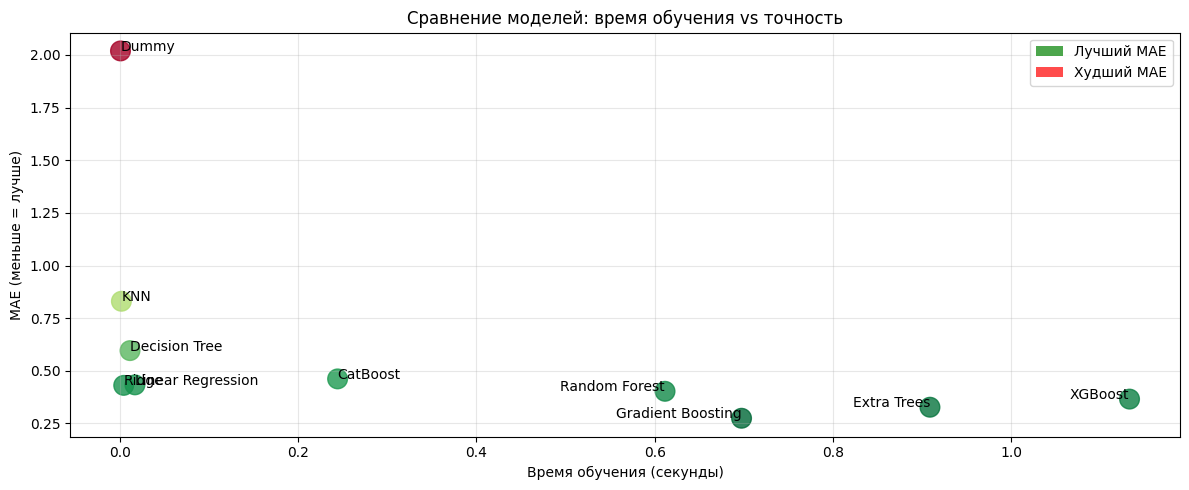

ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ


,Модель,MAE,Время (сек)
0,Dummy,2.019155,0.000590
3,KNN,0.830089,0.001615
2,Ridge,0.430583,0.004206
4,Decision Tree,0.595768,0.011292
1,Linear Regression,0.433039,0.016808
9,CatBoost,0.461387,0.244187
5,Random Forest,0.402433,0.611562
7,Gradient Boosting,0.274410,0.697417
6,Extra Trees,0.326802,0.908794
8,XGBoost,0.365400,1.132735


In [22]:
# ============================================
# СРАВНЕНИЕ МОДЕЛЕЙ: ВРЕМЯ vs ТОЧНОСТЬ
# ============================================

import time

# Словарь для хранения времени
training_times = {}

# Переобучаем модели и замеряем время
for model_name in results_df['Модель']:
    # Получаем модель из словаря (нужно пересоздать)
    if model_name == 'Dummy':
        model = DummyRegressor(strategy='mean')
        X_train, X_test = X_train_label, X_test_label
    elif model_name == 'Linear Regression':
        model = LinearRegression()
        X_train, X_test = X_train_scaled, X_test_scaled
    elif model_name == 'Ridge':
        model = Ridge(alpha=1.0)
        X_train, X_test = X_train_scaled, X_test_scaled
    elif model_name == 'KNN':
        model = KNeighborsRegressor(n_neighbors=5)
        X_train, X_test = X_train_scaled, X_test_scaled
    elif model_name == 'Decision Tree':
        model = DecisionTreeRegressor(random_state=42)
        X_train, X_test = X_train_label, X_test_label
    elif model_name == 'Random Forest':
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        X_train, X_test = X_train_label, X_test_label
    elif model_name == 'Extra Trees':
        model = ExtraTreesRegressor(n_estimators=100, random_state=42)
        X_train, X_test = X_train_label, X_test_label
    elif model_name == 'Gradient Boosting':
        model = GradientBoostingRegressor(n_estimators=100, random_state=42)
        X_train, X_test = X_train_label, X_test_label
    elif model_name == 'XGBoost':
        model = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
        X_train, X_test = X_train_label, X_test_label
    elif model_name == 'CatBoost':
        model = CatBoostRegressor(n_estimators=100, random_state=42, verbose=False, cat_features=[0, 1, 7])
        X_train, X_test = X_train_catboost, X_test_catboost

    # Замеряем время обучения
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()

    training_times[model_name] = end_time - start_time

# Создаем таблицу
time_df = pd.DataFrame({
    'Модель': results_df['Модель'],
    'MAE': results_df['MAE'],
    'Время (сек)': [training_times[m] for m in results_df['Модель']]
})

# Строим график
fig, ax = plt.subplots(figsize=(12, 5))

# Цвет в зависимости от MAE (зелёный = лучше, красный = хуже)
norm = plt.Normalize(time_df['MAE'].min(), time_df['MAE'].max())
colors = plt.cm.RdYlGn_r(norm(time_df['MAE']))

ax.scatter(time_df['Время (сек)'], time_df['MAE'], s=200, c=colors, alpha=0.8)

# Подписываем точки
for _, row in time_df.iterrows():
    ax.annotate(row['Модель'], (row['Время (сек)'], row['MAE']),
                fontsize=10, ha='left' if row['Время (сек)'] < 0.5 else 'right')

ax.set_xlabel('Время обучения (секунды)')
ax.set_ylabel('MAE (меньше = лучше)')
ax.set_title('Сравнение моделей: время обучения vs точность')
ax.grid(True, alpha=0.3)

# Добавляем легенду
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.7, label='Лучший MAE'),
    Patch(facecolor='red', alpha=0.7, label='Худший MAE')
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

print("="*60)
print("ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ")
print("="*60)
display(time_df.sort_values('Время (сек)'))

========== 9.6 График сравнения фактических/ предсказанных значений лучшей модели

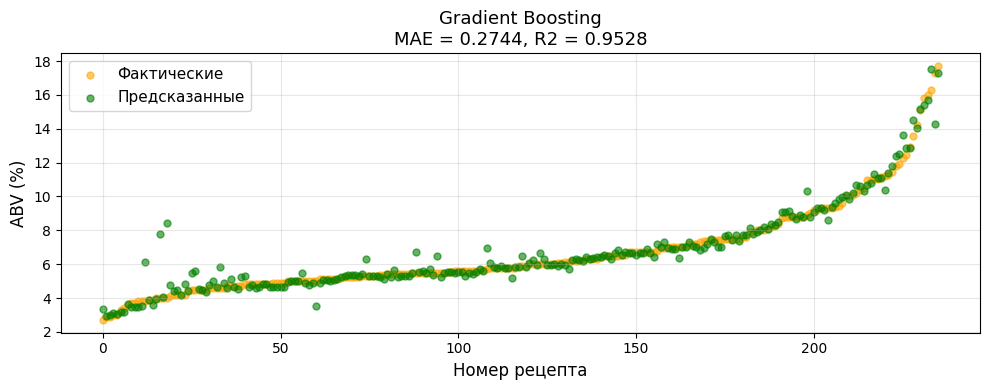

In [23]:

# Данные лучшей модели
best_model = results_df.iloc[0]['Модель']
y_pred = predictions[best_model]
mae = results_df[results_df['Модель'] == best_model]['MAE'].values[0]
r2 = results_df[results_df['Модель'] == best_model]['R2'].values[0]

# Сортировка для графика
sorted_idx = np.argsort(y_test)
y_test_sorted = y_test.iloc[sorted_idx].values
y_pred_sorted = y_pred[sorted_idx]

# Создаём график
fig, ax = plt.subplots(figsize=(10, 4))

# Фактические значения (чёрные точки)
ax.scatter(range(len(y_test_sorted)), y_test_sorted,
           alpha=0.6, s=25, color='orange', label='Фактические')

# Предсказанные значения (синие точки — лучше контраст)
ax.scatter(range(len(y_pred_sorted)), y_pred_sorted,
           alpha=0.6, s=25, color='green', label='Предсказанные')

ax.set_xlabel('Номер рецепта', fontsize=12)
ax.set_ylabel('ABV (%)', fontsize=12)
ax.set_title(f'{best_model}\nMAE = {mae:.4f}, R2 = {r2:.4f}', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

========== 9.7 Сравнение предсказаний лучшей и худшей модели

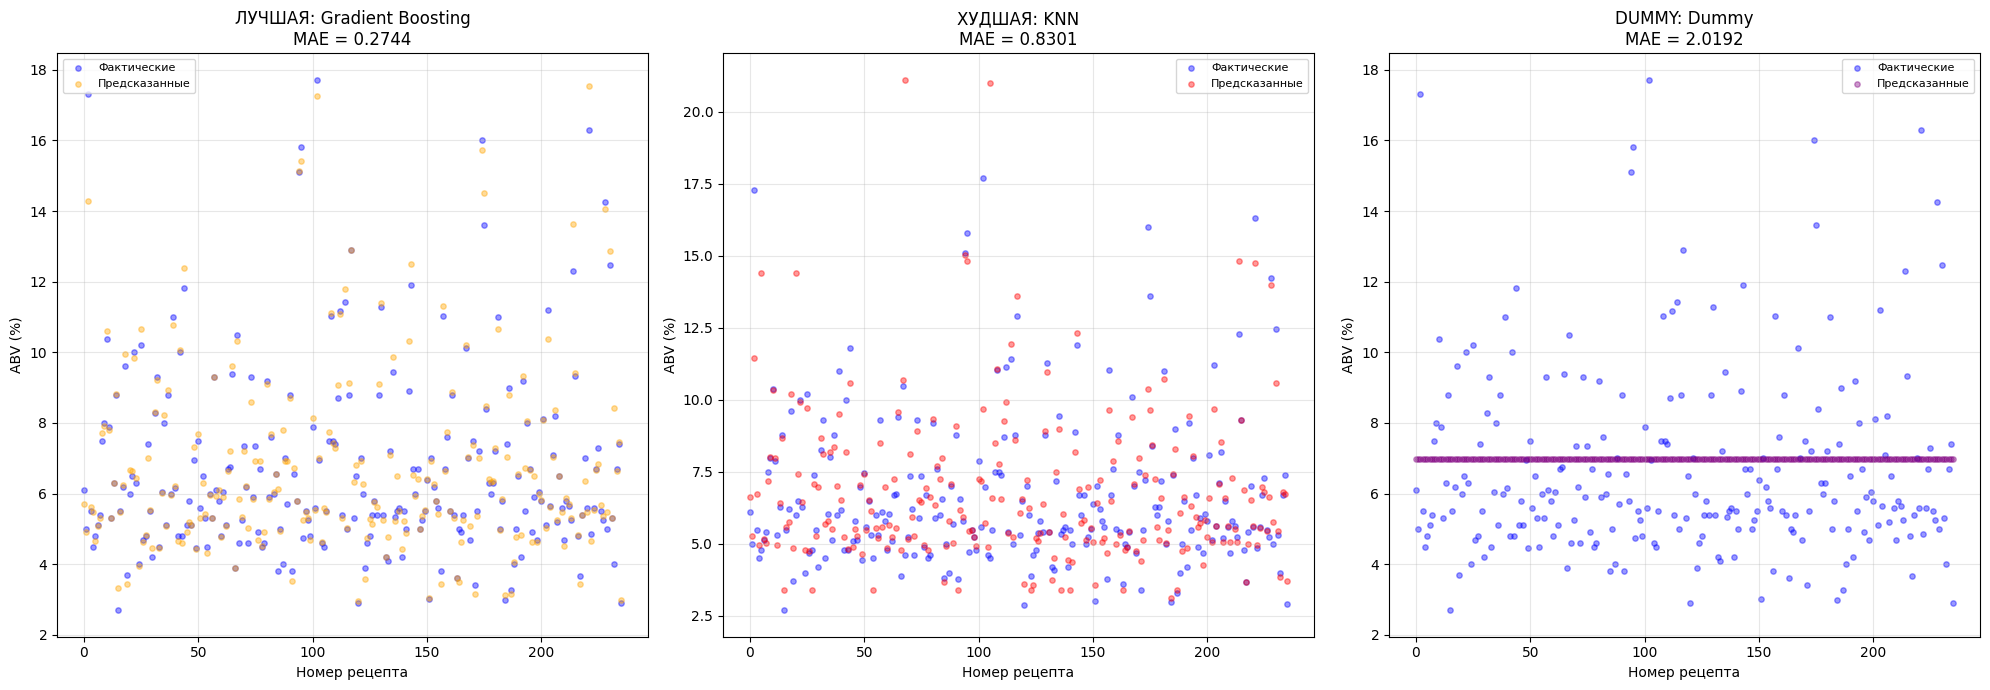

In [24]:

# Определяем модели
best_model = results_df.iloc[0]['Модель']
dummy_model = 'Dummy'
worst_model = results_df.iloc[-2]['Модель'] if results_df.iloc[-1]['Модель'] == 'Dummy' else results_df.iloc[-1]['Модель']

# Подготовка данных
models_to_plot = [best_model, worst_model, dummy_model]
titles = ['ЛУЧШАЯ', 'ХУДШАЯ', 'DUMMY']
colors = ['orange', 'red', 'purple']

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for idx, (model_name, title, color) in enumerate(zip(models_to_plot, titles, colors)):
    ax = axes[idx]
    y_pred = predictions[model_name]
    mae = results_df[results_df['Модель'] == model_name]['MAE'].values[0]

    ax.scatter(range(len(y_test)), y_test, alpha=0.4, s=15, color='blue', label='Фактические')
    ax.scatter(range(len(y_pred)), y_pred, alpha=0.4, s=15, color=color, label='Предсказанные')
    ax.set_xlabel('Номер рецепта')
    ax.set_ylabel('ABV (%)')
    ax.set_title(f'{title}: {model_name}\nMAE = {mae:.4f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


========== 10. КОРРЕЛЯЦИЯ ПРИЗНАКОВ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ==========

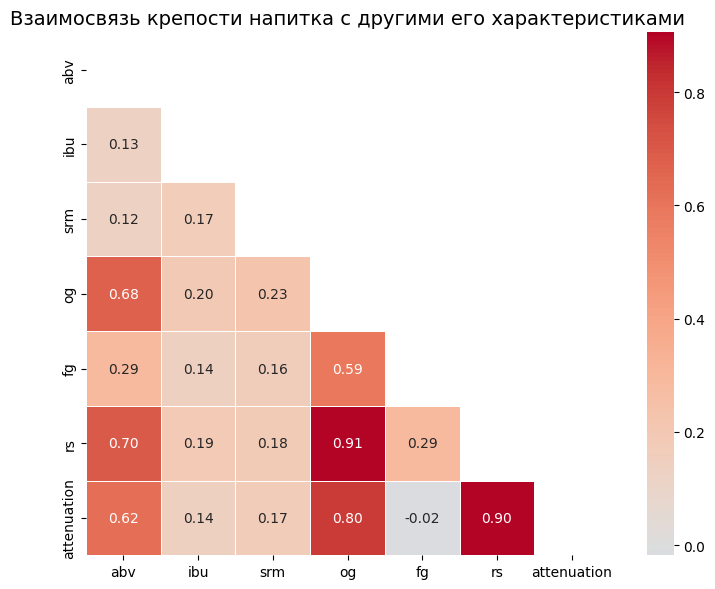

In [25]:

# Выбираем числовые признаки для корреляции
numeric_cols = ['abv', 'ibu', 'srm', 'og', 'fg', 'rs', 'attenuation']

# Считаем матрицу корреляции
corr_matrix = df_clean[numeric_cols].corr()

# Строим тепловую карту
fig, ax = plt.subplots(figsize=(8, 6))

# Маска для верхней половины (чтобы не дублировать)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,           # показываем числа
    fmt='.2f',            # 2 знака после запятой
    cmap='coolwarm',      # красный = положительная, синий = отрицательная
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Взаимосвязь крепости напитка с другими его характеристиками', fontsize=14)

plt.tight_layout()
plt.show()

**abv**      -   Alcohol By Volume - объемная доля алкоголя (в процентах)

**ibu**      -     International Bitterness Units - международные единицы горечи (чем выше значение, тем более горькое пиво)

**srm**      -     Standard Reference Method - цвет пива (чем выше число, тем темнее пиво)

**og**       -      Original Gravity - начальная плотность сусла до брожения. Измеряет количество сахара в растворе (чем выше OG, тем больше потенциального алкоголя)

**fg**       -       Final Gravity - конечная плотность после брожения. Показывает, сколько сахара осталось (разница OG - FG определяет количество алкоголя)

**rs**       -      Residual Sugar - остаточный сахар (в процентах). Показывает, сколько сахара осталось в напитке после брожения

**attenuation** - брожение, степень превращения сахара в спирт